# 5주차: Deep Neural Network — 여러 층 쌓기, 행렬 차원, 하이퍼파라미터

> **수업 구성**
> - Part 1 (강의 영상 ~40분): 이론 설명 — 미리 보고 오세요
> - Part 2 (교실 실습 100분): 빈칸 채우기 실습

---

## 0. 지난 주 복습 & 이번 주 연결

4주차에서 우리는 **은닉층 1개**짜리 MLP로 XOR 문제를 해결했습니다.

```
입력층 (2) → 은닉층 (4) → 출력층 (1)
```

핵심 교훈:
- 은닉층이 없으면 비선형 문제를 풀 수 없다
- 활성화 함수가 없으면 레이어를 쌓아도 선형 변환과 동일하다
- 학습 루프 5단계는 변하지 않는다

이번 주 질문: **은닉층을 여러 개 쌓으면 무슨 일이 일어날까요?**

```
입력층 → 은닉층1 → 은닉층2 → … → 은닉층L → 출력층
```

이것이 바로 **Deep Neural Network (DNN)** 입니다.


## 1. 왜 깊게(Deep) 쌓을까?

### 계층적 표현 학습 (Hierarchical Representation)

각 레이어는 점점 더 **추상적인 특징**을 학습합니다.

```
픽셀값 → 엣지/선 → 곡선/패턴 → 부품(눈,코) → 얼굴
 (1층)     (2층)      (3층)         (4층)         (5층)
```

### "넓게" vs "깊게"

| 비교 | 넓은 네트워크 (1층, 뉴런 多) | 깊은 네트워크 (多층, 뉴런 少) |
|------|------|------|
| 표현력 | 이론적으로 가능하지만 비효율 | 같은 파라미터로 더 복잡한 함수 표현 |
| 파라미터 수 | 폭발적으로 증가 | 상대적으로 적음 |
| 실전 성능 | 낮음 | 높음 |

> 이론적으로 은닉층 1개만으로도 모든 연속 함수를 근사할 수 있습니다 (Universal Approximation Theorem).
> 하지만 필요한 뉴런 수가 지수적으로 증가하여 실용적이지 않습니다.


## 2. 행렬 차원 추적 — L개 레이어

### 표기법

- $m$: 배치(샘플) 수, $\ n^{[l]}$: $l$번째 레이어 뉴런 수
- $W^{[l]} \in \mathbb{R}^{n^{[l]} \times n^{[l-1]}}$, $\ b^{[l]} \in \mathbb{R}^{n^{[l]}}$

### Forward Pass

| 레이어 | &nbsp;&nbsp;입력 shape &nbsp;&nbsp;| 출력 shape |
|--------|-----------|-----------|
| 1 | $(m,\ n^{[0]})$ | $(m,\ n^{[1]})$ |
| 2 | $(m,\ n^{[1]})$ | $(m,\ n^{[2]})$ |
| $\vdots$ | $\vdots$ | $\vdots$ |
| L | $(m,\ n^{[L-1]})$ | $(m,\ n^{[L]})$ |

각 레이어의 연산:

$$Z^{[l]} = A^{[l-1]} {W^{[l]}}^T + b^{[l]}, \qquad A^{[l]} = g\!\left(Z^{[l]}\right)$$

> PyTorch의 `nn.Linear(in, out)`은 내부적으로 $W \in \mathbb{R}^{out \times in}$을 저장하고
> `x @ W.T + b` 연산을 수행합니다.


In [11]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

print("=== Dimension flow: [10 → 64 → 32 → 16 → 1] ===\n")
dims = [10, 64, 32, 16, 1]
x = torch.randn(32, dims[0])
print(f"Input:    {tuple(x.shape)}")
print(f"Input:    {x.shape}") # tuple 자료형이 아니면 torch.Size로 출력됨
for i in range(1, len(dims)):
    x = nn.Linear(dims[i-1], dims[i])(x)
    print(f"Layer {i} (Linear {dims[i-1]:2d}→{dims[i]:2d}): {tuple(x.shape)}")


=== Dimension flow: [10 → 64 → 32 → 16 → 1] ===

Input:    (32, 10)
Input:    torch.Size([32, 10])
Layer 1 (Linear 10→64): (32, 64)
Layer 2 (Linear 64→32): (32, 32)
Layer 3 (Linear 32→16): (32, 16)
Layer 4 (Linear 16→ 1): (32, 1)


## 3. PyTorch로 DNN 구현하기

### `nn.ModuleList` 방식 (유연한 깊이 제어)

```python
class DNN(nn.Module):
    def __init__(self, layer_dims):
        # layer_dims 예시: [2, 16, 8, 1]  DNN([2, 16, 8, 1])
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layer_dims) - 1):
            self.layers.append(nn.Linear(layer_dims[i], layer_dims[i+1]))

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:   # 은닉층: ReLU
                x = torch.relu(x)
        return torch.sigmoid(x)            # 출력층: Sigmoid
```

`nn.ModuleList`를 써야 PyTorch가 내부 파라미터를 추적할 수 있습니다.
일반 Python 리스트를 쓰면 `optimizer`가 파라미터를 찾지 못합니다!


In [12]:
class DNN(nn.Module):
    def __init__(self, layer_dims):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layer_dims) - 1):
            self.layers.append(nn.Linear(layer_dims[i], layer_dims[i+1]))
        # print(self.layers)

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = torch.relu(x)
        return torch.sigmoid(x)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

configs = {
    "Shallow (1 hidden)": [2, 8, 1],
    "Medium  (2 hidden)": [2, 16, 8, 1],
    "Deep    (4 hidden)": [2, 32, 16, 8, 4, 1],
}
print(f"{'Architecture':30s} {'Params':>8s}  Dims")
print("-" * 60)
for name, dims in configs.items():
    print(f"{name:30s} {DNN(dims).count_params():>8,}  {dims}")


Architecture                     Params  Dims
------------------------------------------------------------
Shallow (1 hidden)                   33  [2, 8, 1]
Medium  (2 hidden)                  193  [2, 16, 8, 1]
Deep    (4 hidden)                  801  [2, 32, 16, 8, 4, 1]


## 4. 하이퍼파라미터란?

학습으로 **자동으로 결정되는 값** (파라미터): $W$, $b$

우리가 **직접 설정해야 하는 값** (하이퍼파라미터):

| 하이퍼파라미터 | 의미 | 예시 |
|---|---|---|
| 레이어 수 (depth) | 은닉층 몇 개? | 2, 3, 5 |
| 뉴런 수 (width) | 각 층에 몇 개? | 16, 64, 256 |
| 학습률 | 한 번에 얼마나 이동? | 0.001, 0.01 |
| 에폭 수 | 데이터를 몇 번 반복? | 100, 500, 1000 |
| 활성화 함수 | ReLU? Tanh? | relu, tanh |
| 배치 크기 | 한 번에 몇 개 샘플? | 32, 64, 128 (7주차) |

> 하이퍼파라미터 최적화(튜닝)는 8주차에서 체계적으로 다룹니다.


## 5. 깊이(Depth) vs 너비(Width) 실험

같은 수준의 파라미터, 다른 구조 — 어느 것이 더 잘 학습할까요?


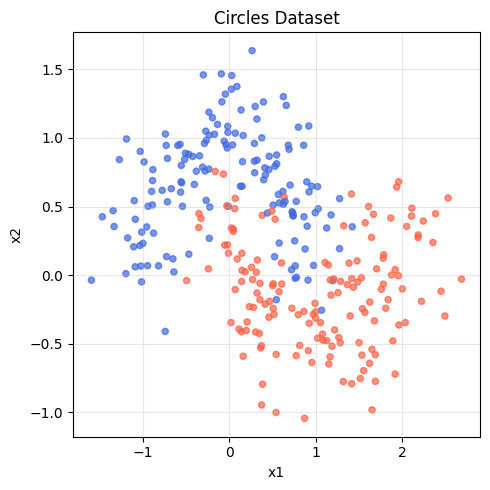

In [13]:
X_np, y_np = make_moons(n_samples=300, noise=0.25, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

X_train = torch.tensor(X_tr, dtype=torch.float32)
y_train = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_te, dtype=torch.float32)
y_test  = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_np[:,0], X_np[:,1],
           c=['royalblue' if l==0 else 'tomato' for l in y_np], s=20, alpha=0.7)
ax.set_title("Circles Dataset"); ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


In [14]:
def train_model(layer_dims, epochs=1500, lr=0.01):
    torch.manual_seed(42)
    model = DNN(layer_dims)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    crit  = nn.BCELoss()
    losses = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = crit(model(X_train), y_train)
        loss.backward(); opt.step()
        losses.append(loss.item())
    with torch.no_grad():
        acc = ((model(X_test) > 0.5).float() == y_test).float().mean().item()
    return model, losses, acc

experiments = {
    "1 hidden  [2-2-1]":       [2, 2, 1],
    "2 hidden  [2-16-1]":    [2, 16, 1],
    "3 hidden  [2-4-4-4-1]": [2, 4, 4, 4, 1],
    "4 hidden  [2-4-4-4-4-1]": [2, 4, 4, 4, 4, 1],
}

results = {}
for name, dims in experiments.items():
    model, losses, acc = train_model(dims)
    results[name] = (model, losses, acc, DNN(dims).count_params())
    print(f"{name:35s} params={results[name][3]:5d}  acc={acc*100:.1f}%")


1 hidden  [2-2-1]                   params=    9  acc=88.3%
2 hidden  [2-16-1]                  params=   65  acc=91.7%
3 hidden  [2-4-4-4-1]               params=   57  acc=95.0%
4 hidden  [2-4-4-4-4-1]             params=   77  acc=95.0%


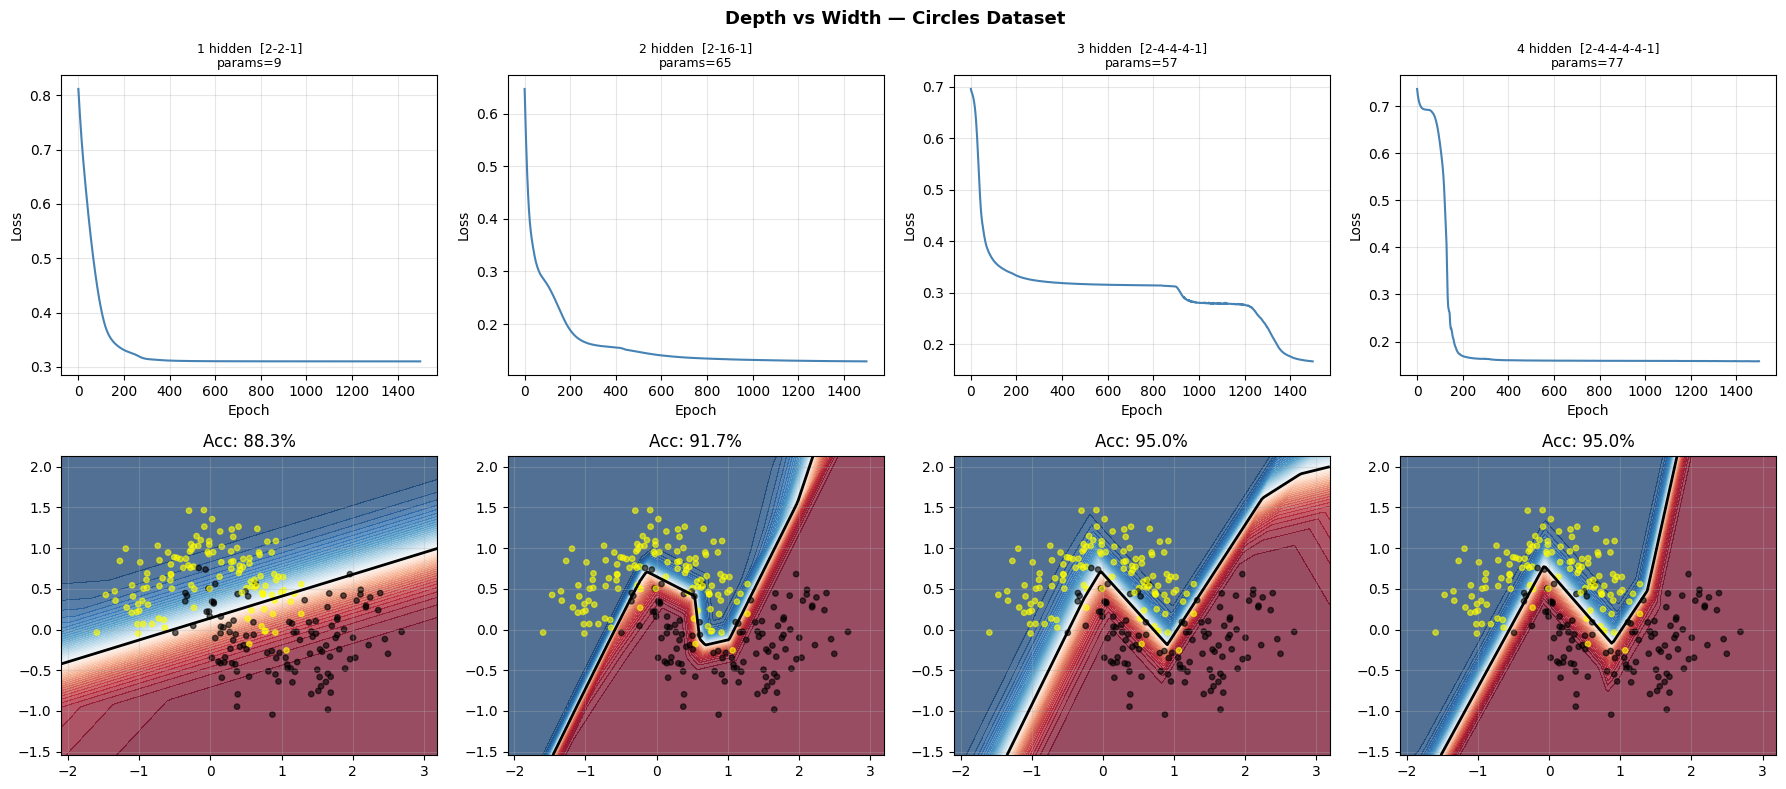

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
xx, yy = np.meshgrid( #np.linspace(-1.5,1.5,200), np.linspace(-1.5,1.5,200))
    np.linspace(X_np[:,0].min()-0.5, X_np[:,0].max()+0.5, 200),\
    np.linspace(X_np[:,1].min()-0.5, X_np[:,1].max()+0.5, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

for col, (name, (model, losses, acc, params)) in enumerate(results.items()):
    axes[0][col].plot(losses, color='steelblue', lw=1.5)
    axes[0][col].set_title(f"{name}\nparams={params}", fontsize=9)
    axes[0][col].set_xlabel("Epoch"); axes[0][col].set_ylabel("Loss")
    axes[0][col].grid(True, alpha=0.3)

    with torch.no_grad():
        zz = model(grid).reshape(xx.shape).numpy()
    axes[1][col].contourf(xx, yy, zz, levels=50, cmap='RdBu_r', alpha=0.7)
    axes[1][col].contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2)
    axes[1][col].scatter(X_tr[:,0], X_tr[:,1],
                         c=['yellow' if l==0 else 'black' for l in y_tr], s=15, alpha=0.6)
    axes[1][col].set_title(f"Acc: {acc*100:.1f}%"); axes[1][col].grid(True, alpha=0.3)

plt.suptitle("Depth vs Width — Circles Dataset", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 6. 모델 내부 탐색

In [16]:
model_viz = DNN([2, 8, 4, 1])

print("=== named_parameters() ===")
for name, param in model_viz.named_parameters():
    print(f"  {name:25s} shape={tuple(param.shape)}  numel={param.numel()}")

print(f"\nTotal: {model_viz.count_params()} params")  # x @ W.T + b


=== named_parameters() ===
  layers.0.weight           shape=(8, 2)  numel=16
  layers.0.bias             shape=(8,)  numel=8
  layers.1.weight           shape=(4, 8)  numel=32
  layers.1.bias             shape=(4,)  numel=4
  layers.2.weight           shape=(1, 4)  numel=4
  layers.2.bias             shape=(1,)  numel=1

Total: 65 params


## 7. 모델 저장과 불러오기

In [17]:
'''
import os
import torch
# 원격 서버(T4)에 colab 유틸리티 강제 설치
!pip install google-colab
from google.colab import drive

# 1. Google Drive 마운트
# 실행 시 VS Code 상단에 인증 팝업이 뜨면 승인 절차를 진행합니다.
drive.mount('/content/drive')'''

"\nimport os\nimport torch\n# 원격 서버(T4)에 colab 유틸리티 강제 설치\n!pip install google-colab\nfrom google.colab import drive\n\n# 1. Google Drive 마운트\n# 실행 시 VS Code 상단에 인증 팝업이 뜨면 승인 절차를 진행합니다.\ndrive.mount('/content/drive')"

In [18]:
import os
import torch

# 현재 작업 디렉토리에 'weights' 폴더 생성
save_dir = "./weights"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

def save_model(model, epoch):
    # f-string을 활용한 동적 파일명 생성
    path = os.path.join(save_dir, f"model_epoch_{epoch}.pth")
    torch.save(model.state_dict(), path)
    print(f"Saved: {path}")

# 학습 코드...
# save_model(my_model, current_epoch)

In [19]:
model_save, _, acc_save = train_model([2, 16, 8, 1], epochs=500)
print(f"Trained accuracy: {acc_save*100:.1f}%")

torch.save(model_save.state_dict(), "/tmp/week5_model.pth")
print("Saved.")

model_loaded = DNN([2, 16, 8, 1])
model_loaded.load_state_dict(torch.load("/tmp/week5_model.pth", weights_only=True))
model_loaded.eval()

with torch.no_grad():
    acc_loaded = ((model_loaded(X_test) > 0.5).float() == y_test).float().mean().item()
print(f"Loaded accuracy:  {acc_loaded*100:.1f}%  (should match)")


Trained accuracy: 95.0%
Saved.
Loaded accuracy:  95.0%  (should match)


In [20]:
#from google.colab import drive
#drive.mount('/content/drive')

## 8. 다음 주 예고 — 실전 딥러닝 1

DNN을 자유롭게 쌓을 수 있게 됐지만, 실제 훈련에서 자주 만나는 문제들:

- 훈련엔 잘 맞지만 테스트에서 엉망 → **Overfitting**
- 훈련도 테스트도 모두 안 됨 → **Underfitting**
- 깊은 네트워크 앞쪽 레이어가 학습이 안 됨 → **Vanishing Gradient**

6주차 해결책: **L2 정규화, Dropout, Xavier/He 초기화**

---
**Part 2 실습으로 넘어가세요 ↓**


---
# Part 2: 실습 (교실 100분)

> - `______` 를 올바른 코드로 채우세요.
> - [A]는 한 줄, [B]는 여러 줄 채우기입니다.

---

In [21]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons
from sklearn.model_selection import train_test_split
torch.manual_seed(42); np.random.seed(42)


## [A] 한 줄 채우기

---
### A-1. 행렬 차원 계산

구조: `Linear(4→16)` → ReLU → `Linear(16→8)` → ReLU → `Linear(8→1)` → Sigmoid

입력 `(32, 4)` 가 각 레이어를 통과하면 shape가 어떻게 바뀔까요?
직접 예측한 뒤 코드로 확인하세요.


In [22]:
x = torch.randn(32, 4)
fc1 = nn.Linear(4, 16); fc2 = nn.Linear(16, 8); fc3 = nn.Linear(8, 1)               

a1  = torch.relu(fc1(x))
print("After fc1 + ReLU:    ", a1.shape)   # 예상: torch.Size([32, 16])                                            

a2  = torch.relu(fc2(a1))                                                                                                                                                     
print("After fc2 + ReLU:    ", a2.shape)   # 예상: torch.Size([32, 8])
                  
out = torch.sigmoid(fc3(a2))
print("After fc3 + Sigmoid: ", out.shape)   # 예상: torch.Size([32, 1])


After fc1 + ReLU:     torch.Size([32, 16])
After fc2 + ReLU:     torch.Size([32, 8])
After fc3 + Sigmoid:  torch.Size([32, 1])


---
### A-2. DNN `forward` 완성

마지막 레이어가 아니면 ReLU, 마지막이면 Sigmoid를 적용하세요.


In [23]:
class MyDNN(nn.Module):
    def __init__(self, layer_dims):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(layer_dims[i], layer_dims[i+1])
            for i in range(len(layer_dims)-1)
        ])
    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:           # 마지막 레이어가 아닌 조건
                x = torch.relu(x)
            else:
                x = torch.sigmoid(x)
        return x

print("Output shape:", MyDNN([3,8,4,1])(torch.randn(10,3)).shape)  # [10, 1]


Output shape: torch.Size([10, 1])


---
### A-3. 파라미터 수 계산

직접 계산한 뒤 코드로 확인하세요.

$$\text{Linear}(n \to m)\ \text{파라미터 수} = n \times m + m$$

- 모델 A `[2, 32, 1]`: $\ (2 \times 32 + 32) + (32 \times 1 + 1) = ?$
- 모델 B `[2, 8, 8, 8, 1]`: 직접 계산해보세요


In [24]:
class DNN(nn.Module):
    def __init__(self, layer_dims):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(layer_dims[i], layer_dims[i+1]) for i in range(len(layer_dims)-1)
        ])
    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers)-1: x = torch.relu(x)
        return torch.sigmoid(x)
    def count_params(self):
        return sum(p.numel() for p in self.parameters())

params_A = DNN([2, 32, 1]).count_params()
params_B = DNN([2, 8, 8, 8, 1]).count_params()

print(f"Model A [2-32-1]:    {params_A:5d} params")
print(f"Model B [2-8-8-8-1]: {params_B:5d} params")


Model A [2-32-1]:      129 params
Model B [2-8-8-8-1]:   177 params


---
### A-4. `nn.ModuleList` vs Python list

어떤 차이가 있는지 직접 확인하세요.


In [25]:
class GoodDNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(2,4), nn.Linear(4,1)])
    def count_params(self):
        return sum(p.numel() for p in self.parameters())

class BadDNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = [nn.Linear(2,4), nn.Linear(4,1)]  # plain list!
    def count_params(self):
        return sum(p.numel() for p in self.parameters())

good_params = GoodDNN().count_params()
bad_params  = BadDNN().count_params()

print(f"GoodDNN (ModuleList) params: {good_params}")   # > 0
print(f"BadDNN  (plain list) params: {bad_params}")    # 0 ← bug!


GoodDNN (ModuleList) params: 17
BadDNN  (plain list) params: 0


---
### A-5. `model.train()` / `model.eval()` 위치

올바른 위치에 채우세요. (지금 당장 차이는 없지만 Dropout 추가 시 필수!)


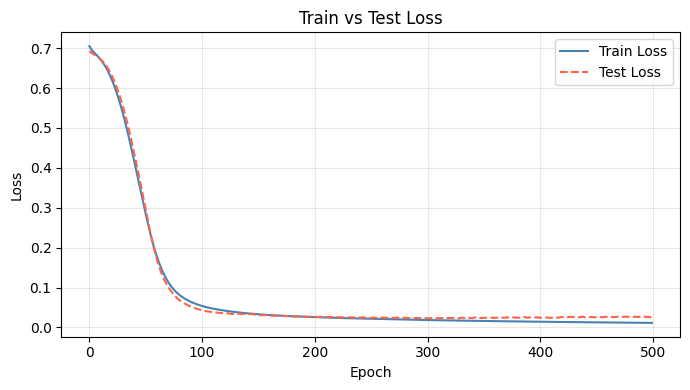

In [26]:
X_np2, y_np2 = make_circles(n_samples=400, noise=0.15, factor=0.4, random_state=0)
X_tr2,X_te2,y_tr2,y_te2 = train_test_split(X_np2,y_np2,test_size=0.2,random_state=0)
X_train2=torch.tensor(X_tr2,dtype=torch.float32); y_train2=torch.tensor(y_tr2,dtype=torch.float32).unsqueeze(1)
X_test2 =torch.tensor(X_te2,dtype=torch.float32); y_test2 =torch.tensor(y_te2,dtype=torch.float32).unsqueeze(1)

torch.manual_seed(42)
model_a5 = DNN([2,16,8,1])
opt_a5   = torch.optim.Adam(model_a5.parameters(), lr=0.01)
crit_a5  = nn.BCELoss()
train_losses, test_losses = [], []

for epoch in range(500):
    model_a5.train()   # 훈련 모드
    opt_a5.zero_grad()
    loss = crit_a5(model_a5(X_train2), y_train2)
    loss.backward(); opt_a5.step()
    train_losses.append(loss.item())

    model_a5.eval()                   # 평가 모드
    with torch.no_grad():
        test_losses.append(crit_a5(model_a5(X_test2), y_test2).item())

plt.figure(figsize=(7,4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(test_losses,  label='Test Loss',  color='tomato', linestyle='--')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Train vs Test Loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


---
### A-6. 구조 비교표 출력


In [27]:
architectures = [
    [2,128,1], [2,64,64,1], [2,32,32,32,1], [2,16,16,16,16,1], [2,8,8,8,8,8,1]
]

print(f"{'Architecture':35s} {'Depth':>6s} {'Params':>8s}")
print("-" * 55)
for dims in architectures:
    depth  = len(dims) - 2   # 은닉층 수
    params = DNN(dims).count_params()   # 파라미터 수
    print(f"{str(dims):35s} {depth:>6d} {params:>8,}")


Architecture                         Depth   Params
-------------------------------------------------------
[2, 128, 1]                              1      513
[2, 64, 64, 1]                           2    4,417
[2, 32, 32, 32, 1]                       3    2,241
[2, 16, 16, 16, 16, 1]                   4      881
[2, 8, 8, 8, 8, 8, 1]                    5      321


---
### A-7. 모델 저장·불러오기


In [28]:
X_np3,y_np3=make_circles(n_samples=400,noise=0.15,factor=0.4,random_state=0)
X_tr3,X_te3,y_tr3,y_te3=train_test_split(X_np3,y_np3,test_size=0.2,random_state=0)
X_train3=torch.tensor(X_tr3,dtype=torch.float32); y_train3=torch.tensor(y_tr3,dtype=torch.float32).unsqueeze(1)
X_test3 =torch.tensor(X_te3,dtype=torch.float32); y_test3 =torch.tensor(y_te3,dtype=torch.float32).unsqueeze(1)

torch.manual_seed(42)
model_save = DNN([2,16,8,1])
opt_s=torch.optim.Adam(model_save.parameters(),lr=0.01); crit_s=nn.BCELoss()
for _ in range(300):
    opt_s.zero_grad(); l=crit_s(model_save(X_train3),y_train3); l.backward(); opt_s.step()

torch.save(model_save.state_dict(), "/tmp/my_dnn.pth")     # state_dict 저장
print("Saved!")

model_load = DNN([2,16,8,1])
model_load.load_state_dict(torch.load("/tmp/my_dnn.pth"))        # 불러오기
model_load.eval()
with torch.no_grad():
    acc=((model_load(X_test3)>0.5).float()==y_test3).float().mean().item()
print(f"Loaded acc: {acc*100:.1f}%")


Saved!
Loaded acc: 98.8%


---
### A-8. 결정경계 계산

`grid_a8` 을 모델에 통과시켜 결정경계를 계산하는 한 줄을 완성하세요.


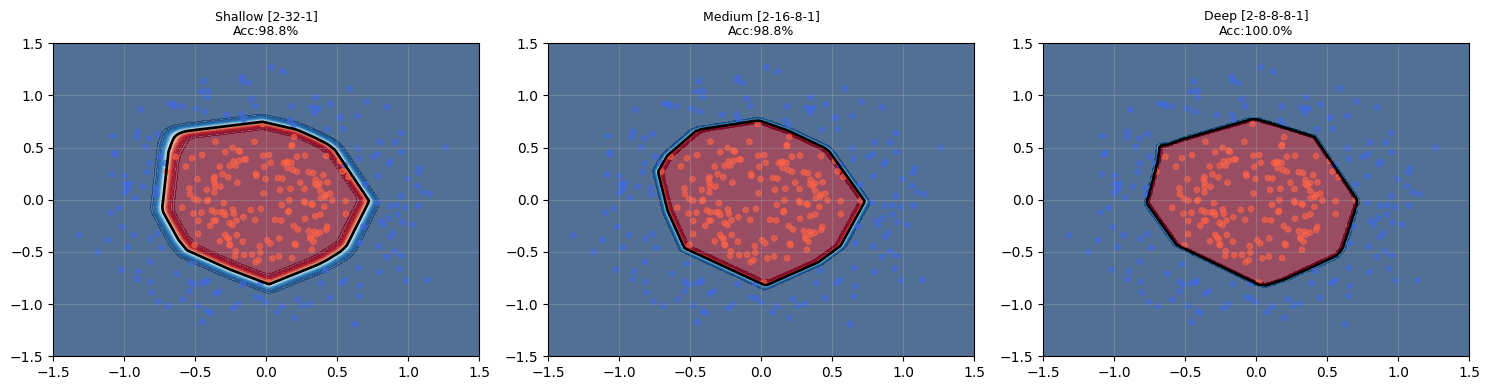

In [29]:
X_np4, y_np4 = make_circles(n_samples=400,noise=0.15,factor=0.4,random_state=0)
X_tr4,X_te4,y_tr4,y_te4 = train_test_split(X_np4,y_np4,test_size=0.2,random_state=0)
X_train4 = torch.tensor(X_tr4,dtype=torch.float32); y_train4=torch.tensor(y_tr4,dtype=torch.float32).unsqueeze(1)
X_test4 = torch.tensor(X_te4,dtype=torch.float32); y_test4 =torch.tensor(y_te4,dtype=torch.float32).unsqueeze(1)

configs_a8 = {"Shallow [2-32-1]":[2,32,1],"Medium [2-16-8-1]":[2,16,8,1],"Deep [2-8-8-8-1]":[2,8,8,8,1]}
fig,axes = plt.subplots(1,3,figsize=(15,4))
xx, yy = np.meshgrid(np.linspace(-1.5,1.5,200),np.linspace(-1.5,1.5,200))
grid_a8 = torch.tensor(np.c_[xx.ravel(),yy.ravel()],dtype=torch.float32)

for col,(name,dims) in enumerate(configs_a8.items()):
    torch.manual_seed(42)
    m=DNN(dims); o=torch.optim.Adam(m.parameters(),lr=0.01); c=nn.BCELoss()
    for _ in range(1000):
        o.zero_grad(); l=c(m(X_train4),y_train4); l.backward(); o.step()
    with torch.no_grad():
        acc=((m(X_test4)>0.5).float()==y_test4).float().mean().item()
        zz = m(grid_a8).reshape(xx.shape).numpy()

    axes[col].contourf(xx,yy,zz,levels=50,cmap='RdBu_r',alpha=0.7)
    axes[col].contour(xx,yy,zz,levels=[0.5],colors='black',linewidths=2)
    axes[col].scatter(X_tr4[:,0],X_tr4[:,1],
                      c=['royalblue' if lb==0 else 'tomato' for lb in y_tr4],s=15,alpha=0.6)
    axes[col].set_title(f"{name}\nAcc:{acc*100:.1f}%",fontsize=9); axes[col].grid(True,alpha=0.3)
plt.tight_layout(); plt.show()


---
## [B] 여러 줄 채우기

---
### B-1. Moon 데이터 — 최적 구조 탐색

`layer_configs` 중 **Test Accuracy가 가장 높은 구조**를 찾으세요.


In [ ]:
X_m,y_m=make_moons(n_samples=600,noise=0.2,random_state=42)
X_mtr,X_mte,y_mtr,y_mte=train_test_split(X_m,y_m,test_size=0.2,random_state=42)
Xmt=torch.tensor(X_mtr,dtype=torch.float32); ymt=torch.tensor(y_mtr,dtype=torch.float32).unsqueeze(1)
Xme=torch.tensor(X_mte,dtype=torch.float32); yme=torch.tensor(y_mte,dtype=torch.float32).unsqueeze(1)

layer_configs = [[2,4,1],[2,16,1],[2,8,8,1],[2,16,8,4,1],[2,32,16,8,1]]
best_acc=0; best_dims=None; results_b1={}

for dims in layer_configs:
    torch.manual_seed(42)
    ______   # 모델
    ______   # optimizer
    ______   # loss function

    for _ in range(______):
        ______; ______; ______; ______; ______

    with torch.no_grad():
        ______; ______

    results_b1[str(dims)] = acc_b1
    if acc_b1 > best_acc: best_acc=acc_b1; best_dims=dims

print(f"{'Architecture':30s} {'Acc':>8s}"); print("-"*42)
for arch,v in results_b1.items():
    marker=" <- BEST" if str(best_dims)==arch else ""
    print(f"{arch:30s} {v*100:>6.1f}%{marker}")


NameError: name '______' is not defined

---
### B-2. (숙제 가능) Overfitting 관찰

Train Loss는 계속 감소하는데 Test Loss는 증가하는 현상을 직접 확인하세요.

힌트:
- 매우 큰 모델 `[2, 256, 256, 1]` + 작은 데이터(n=300) → overfitting 유발
- 두 모델을 같은 조건으로 학습 후 Train/Test Loss 곡선 비교
- 갈라지는 지점(divergence point)을 찾아보세요 → 6주차 early stopping 복선


In [ ]:
X_small,y_small=make_moons(n_samples=300,noise=0.2,random_state=42)
Xs_tr,Xs_te,ys_tr,ys_te=train_test_split(X_small,y_small,test_size=0.3,random_state=42)
Xstr=torch.tensor(Xs_tr,dtype=torch.float32); ystr=torch.tensor(ys_tr,dtype=torch.float32).unsqueeze(1)
Xste=torch.tensor(Xs_te,dtype=torch.float32); yste=torch.tensor(ys_te,dtype=torch.float32).unsqueeze(1)

def train_with_history(layer_dims, epochs=2000, lr=0.01):
    ______; ______; ______
    train_hist, test_hist = [], []
    for _ in range(epochs):
        ______; ______; ______; ______; ______
        train_hist.append(______)
        with torch.no_grad():
            ______; test_hist.append(______)
    with torch.no_grad():
        acc=((model(Xste)>0.5).float()==yste).float().mean().item()
    return train_hist, test_hist, acc

tr_o,te_o,acc_o = train_with_history([2,256,256,1])
tr_g,te_g,acc_g = train_with_history([2,16,1])

fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,tr,te,acc,title in zip(axes,[tr_o,tr_g],[te_o,te_g],[acc_o,acc_g],
        ["Overfit [2-256-256-1]","Good-fit [2-16-1]"]):
    ______; ______
    ax.set_title(f"{title}\nTest Acc: {acc*100:.1f}%")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()


---
## ✅ 체크리스트

- [ ] 각 레이어에서 행렬 shape를 손으로 계산할 수 있다
- [ ] `nn.ModuleList`와 Python list의 차이를 이해했다
- [ ] `model.train()` / `model.eval()` 을 올바르게 배치했다
- [ ] 파라미터 수가 비슷해도 구조에 따라 성능이 다름을 확인했다
- [ ] 모델을 저장하고 불러왔다

---
## 💭 생각해볼 질문

1. 파라미터 수가 같을 때 넓은 모델과 깊은 모델 중 어느 것이 더 복잡한 함수를 표현할 수 있을까요?

2. `nn.ModuleList` 대신 Python list를 쓰면 왜 파라미터가 0으로 나올까요?

3. B-2에서 Train/Test Loss가 갈라지는 지점을 찾았나요? 6주차에서 배울 해결책은 무엇일까요?
